# Martin Campos y Francisco Merino

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#https://www.kaggle.com/datasets/saidaminsaidaxmadov/students-academic-performance-dataset
#link data que usamos

#**Contexto**
Este conjunto de datos contiene información sobre el rendimiento académico de los estudiantes en tres asignaturas: matemáticas, ciencias e inglés. También incluye varios factores demográficos y educativos que pueden influir en el rendimiento estudiantil, como el género, el nivel educativo de los padres, el tipo de almuerzo y la participación en un curso de preparación para exámenes.

El objetivo de este conjunto de datos es analizar cómo los diferentes factores afectan los resultados académicos de los estudiantes e identificar patrones en su rendimiento en las distintas asignaturas.

El conjunto de datos consta de 1000 registros de estudiantes, donde cada fila representa a un estudiante individual y cada columna representa una característica o puntuación específica.

# **Variables**

* Género: Indica si el estudiante es hombre o mujer.
* Nivel educativo de los padres: El nivel educativo más alto alcanzado por los padres del estudiante.

* Almuerzo: Tipo de almuerzo que recibe el estudiante (estándar o gratuito/reducido).

* Curso de preparación para exámenes: Indica si el estudiante completó un curso de preparación para exámenes.

* Puntuación de matemáticas: Puntuación del estudiante en matemáticas.

* Puntuación de ciencias: Puntuación del estudiante en ciencias.

* Puntuación de inglés: Calificación del estudiante en inglés.

* Nivel educativo de los padres: El nivel educativo más alto alcanzado por los padres del estudiante.

* Almuerzo: Tipo de almuerzo que recibe el estudiante (estándar o gratuito/reducido).

* Curso de preparación para exámenes: Indica si el estudiante completó un curso de preparación para exámenes.

#**Propósito del análisis**

El conjunto de datos se puede utilizar para:

1. Evaluar el rendimiento general del estudiante

2. Comparar los resultados entre diferentes grupos de estudiantes

3. Analizar el impacto de los cursos de preparación en las calificaciones de los exámenes

4. Identificar las asignaturas en las que los estudiantes obtienen mejores o peores resultados

5. Generar indicadores clave de rendimiento (KPI) relacionados con el desempeño estudiantil

In [ ]:
pd.options.display.max_rows = 9999

In [ ]:
df = pd.read_csv("/content/Performance_of_Stuednts.csv")

In [ ]:
df.head(21)

,gender,race/group,parental education level,lunch,test prep course,math score,science score,english score
0,Female,Group 10,bachelor's degree,standard,none,66,72,74
1,Female,Group 20,some college,standard,completed,69,90,88
2,Female,Group 10,master's degree,standard,none,90,88,93
3,Male,Group 9,associate's degree,free/reduced,none,47,57,44
4,Male,Group 20,some college,standard,none,76,44,75
5,Female,Group 10,associate's degree,standard,none,71,83,78
6,Female,Group 10,some college,standard,completed,79,95,92
7,Male,Group 10,some college,free/reduced,none,40,43,39
8,Male,Group 8,high school,free/reduced,completed,64,64,67
9,Female,Group 10,high school,free/reduced,none,38,60,50


In [ ]:
df.isna().sum()

,0
gender,0
race/group,0
parental education level,0
lunch,0
test prep course,0
math score,0
science score,0
english score,0


In [ ]:
df.to_csv("/content/Performance_of_Stuednts.csv", index=False)

In [ ]:
porcentajePreparados = (df[df['test prep course'] == 'completed']['test prep course'].count() * 1.0 / df['test prep course'].count()) * 100.0
print("El procentaje de preparados es {0:.2f}%".format(porcentajePreparados))

El procentaje de preparados es 35.80%


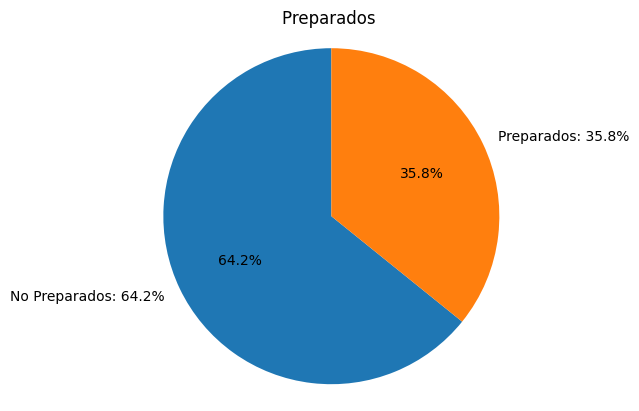

In [ ]:
preparados = df['test prep course'].value_counts()
labels = [ 'Preparados: ' + str(round(x * 1.0 / preparados.sum() * 100.0, 2)) + '%' for x in preparados ]
labels[0] = 'No ' + labels[0]
plt.pie(preparados, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Preparados ')
plt.axis('equal')
plt.show()

In [ ]:
# el 35.8% de los alunmos aprono la evaluacion de preparacion
# mientras que el 64.2% no aprobo la evaluacion de preparacion

In [ ]:
data_preparados = df[df['test prep course'] == 'completed']
print(data_preparados.shape)

(358, 8)


In [ ]:
rango_porcentaje_math = pd.cut(data_preparados['math score'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])



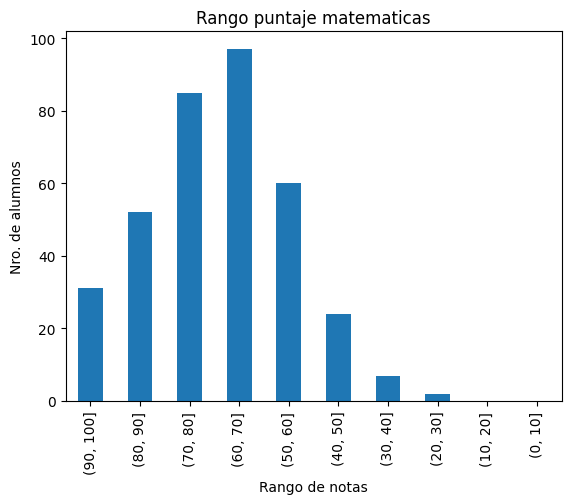

In [ ]:
plot = pd.Series(rango_porcentaje_math).value_counts().sort_index(ascending=False).plot(kind='bar', title='Rango puntaje matematicas')
plot.set_xlabel('Rango de notas')
plot.set_ylabel('Nro. de alumnos')
plt.show()

In [ ]:
rango_porcentaje_science = pd.cut(data_preparados['science score'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])


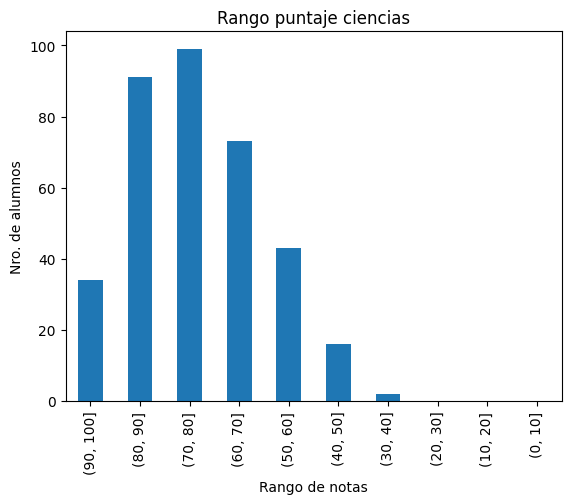

In [ ]:
plot = pd.Series(rango_porcentaje_science).value_counts().sort_index(ascending=False).plot(kind='bar', title='Rango puntaje ciencias')
plot.set_xlabel('Rango de notas')
plot.set_ylabel('Nro. de alumnos')
plt.show()

In [ ]:
rango_porcentaje_eng = pd.cut(data_preparados['english score'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
rango_porcentaje_eng = rango_porcentaje_eng.cat.reorder_categories(rango_porcentaje_eng.cat.categories[::-1], ordered=True)

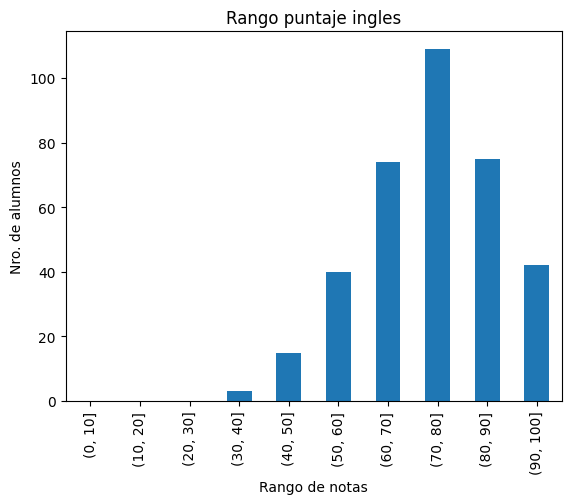

In [ ]:
plot = pd.Series(rango_porcentaje_eng).value_counts().sort_index(ascending=False).plot(kind='bar', title='Rango puntaje ingles')
plot.set_xlabel('Rango de notas')
plot.set_ylabel('Nro. de alumnos')
plt.show()

In [ ]:
TipoAlmuerzo = (df[df['lunch'] == 'free/reduced']['lunch'].count() * 1.0 / df['lunch'].count()) * 100.0
print("El procentaje de alumnos que almuerzan gratuitamente es {0:.2f}%".format(TipoAlmuerzo))

El procentaje de alumnos que almuerzan gratuitamente es 35.50%


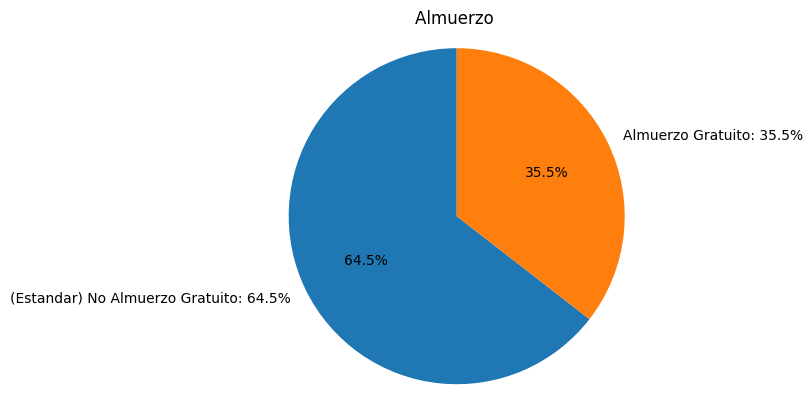

In [ ]:
Almuerzo = df['lunch'].value_counts()
labels = [
    'Almuerzo Gratuito: ' + str(round(x * 1.0 / Almuerzo.sum() * 100.0, 2)) + '%' for x in Almuerzo
          ]
labels[0] = '(Estandar) No ' + labels[0]
plt.pie(Almuerzo, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Almuerzo ')
plt.axis('equal')
plt.show()

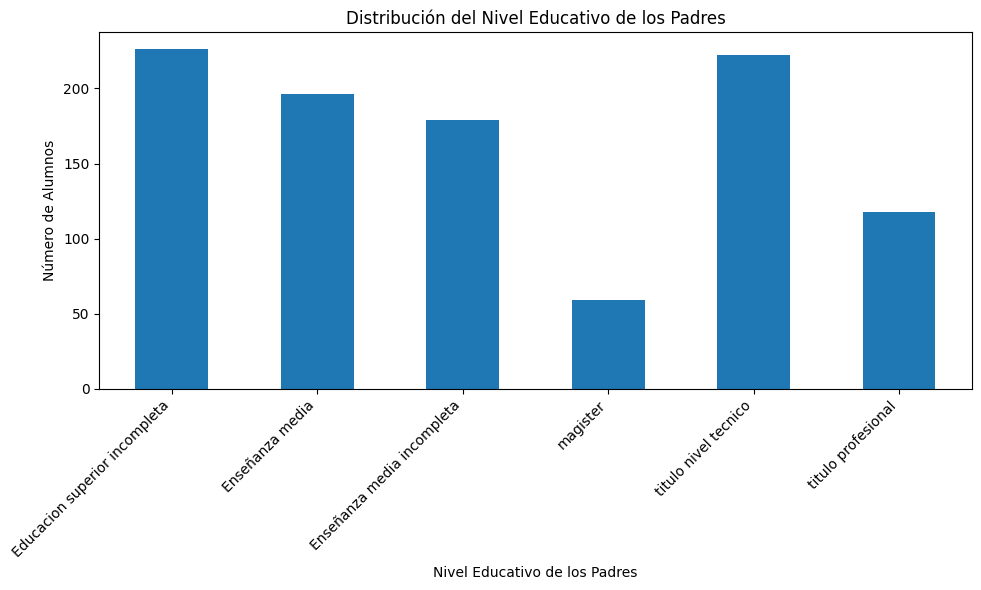

In [ ]:
education_level_mapping = {
    "some high school": "Enseñanza media incompleta",
    "high school": "Enseñanza media",
    "some college": "Educacion superior incompleta",
    "associate's degree": "titulo nivel tecnico",
    "bachelor's degree": "titulo profesional",
    "master's degree": "magister"
}

df_spanish_education = df.copy()
df_spanish_education['parental education level'] = df_spanish_education['parental education level'].replace(education_level_mapping)

plt.figure(figsize=(10, 6))
df_spanish_education['parental education level'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución del Nivel Educativo de los Padres')
plt.xlabel('Nivel Educativo de los Padres')
plt.ylabel('Número de Alumnos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

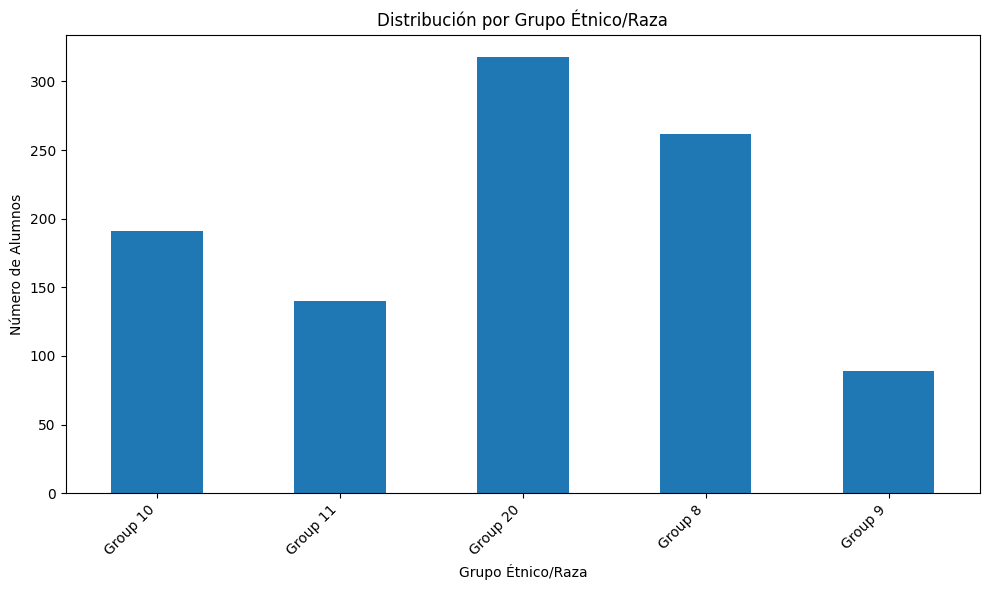

In [ ]:
plt.figure(figsize=(10, 6))
df['race/group'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución por Grupo Étnico/Raza')
plt.xlabel('Grupo Étnico/Raza')
plt.ylabel('Número de Alumnos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()